# Summary

This notebook Contains:
1. Parsing the camera output YAML file
2. Extraction of blue and yellow labeled objects
3. Displaying detailed info for each object either blue or yellow
4. Visualized 2D bounding boxes
5. Visualized 3D positions
6. Providing  statistical comparisons
7. Creating comprehensive comparisons dashboard
8. Exporting the data to CSV files

## 0. Import Required Libraries

In [ ]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Set seaborn style for better-looking plots
sns.set_style("whitegrid")
sns.set_palette("husl")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1. Parsing the Camera Output YAML File

In [ ]:
file_path = 'log11n.txt'

with open(file_path, 'r') as file:
    camera_data = yaml.safe_load(file)

print(f"File loaded successfully")
print(f"\nFrame ID: {camera_data['header']['frame_id']}")
print(f"Timestamp: {camera_data['header']['stamp']['sec']}.{camera_data['header']['stamp']['nanosec']}")
print(f"Total objects detected: {len(camera_data['objects'])}")

File loaded successfully

Frame ID: zed_left_camera_frame
Timestamp: 1765390491.294706347
Total objects detected: 2


## 2. Extraction of Blue and Yellow Labeled Objects

Filter objects based on their label (blue or yellow)

In [ ]:
blue_objects = [obj for obj in camera_data['objects'] if obj.get('label') == 'blue']
yellow_objects = [obj for obj in camera_data['objects'] if obj.get('label') == 'yellow']

print(f"Blue objects found: {len(blue_objects)}")
print(f"Yellow objects found: {len(yellow_objects)}")
print(f"\nTotal colored objects: {len(blue_objects) + len(yellow_objects)}")

all_labels = set(obj.get('label', 'NO_LABEL') for obj in camera_data['objects'])
print(f"\nAll unique labels found: {all_labels}")


Blue objects found: 1
Yellow objects found: 1

Total colored objects: 2

All unique labels found: {'yellow', 'blue'}


## 3. Displaying Detailed Info for Each Object (Blue or Yellow)

Extract key information from each detected object

In [ ]:
def extract_object_info(obj):
    """Extract relevant information from an object"""
    return {
        'Label': obj['label'],
        'Label_ID': obj['label_id'],
        'Sublabel': obj['sublabel'],
        'Confidence (%)': round(obj['confidence'], 2),
        'Position_X': round(obj['position'][0], 4),
        'Position_Y': round(obj['position'][1], 4),
        'Position_Z': round(obj['position'][2], 4),
        'Velocity_X': round(obj['velocity'][0], 4),
        'Velocity_Y': round(obj['velocity'][1], 4),
        'Velocity_Z': round(obj['velocity'][2], 4),
        'Width_3D': round(obj['dimensions_3d'][0], 4),
        'Height_3D': round(obj['dimensions_3d'][1], 4),
        'Depth_3D': round(obj['dimensions_3d'][2], 4),
        'Tracking_State': obj['tracking_state'],
        'Action_State': obj['action_state']
    }

all_colored_objects = blue_objects + yellow_objects
object_data = [extract_object_info(obj) for obj in all_colored_objects]
df = pd.DataFrame(object_data)

print("="*80)
print("DETECTED OBJECTS SUMMARY")
print("="*80)
print(df)

DETECTED OBJECTS SUMMARY
    Label  Label_ID Sublabel  Confidence (%)  Position_X  Position_Y  \
0    blue       740        1           92.87      0.9227      0.5637   
1  yellow       845        0           93.51      1.0257     -0.4366   

   Position_Z  Velocity_X  Velocity_Y  Velocity_Z  Width_3D  Height_3D  \
0     -0.3008      0.0445      0.0183      0.0017    0.2194     0.3387   
1     -0.3306     -0.0044     -0.0192      0.0007    0.2582     0.3837   

   Depth_3D  Tracking_State  Action_State  
0    0.2194               1             0  
1    0.2582               1             0  


_____

_____

## Understanding the Data Fields

**Header Information**
- **stamp**: Timestamp when the data was captured (seconds and nanoseconds)
- **frame_id**: Camera frame identifier

**Object Properties**
- **label**: Object classification (blue/yellow)
- **label_id**: Unique identifier for the label
- **sublabel**: Sub-classification identifier
- **confidence**: Detection confidence score (0-100%)

**Position & Movement**
- **position**: 3D coordinates [X, Y, Z] in meters
- **velocity**: Speed in [X, Y, Z] directions (m/s)
- **position_covariance**: Uncertainty in position measurement

**Bounding Boxes**
- **bounding_box_2d**: 2D box corners in pixel coordinates
- **bounding_box_3d**: 3D box corners in world coordinates
- **dimensions_3d**: Width, Height, Depth of the object

**Tracking**
- **tracking_available**: Whether tracking is active
- **tracking_state**: Current tracking status (1 = OK)
- **action_state**: Current action classification

### Detailed Analysis by Color

In [ ]:
print("="*80)
print("BLUE OBJECTS ANALYSIS")
print("="*80)

for i, obj in enumerate(blue_objects, 1):
    print(f"\n[Blue Object #{i}]")
    print(f"  Label ID: {obj['label_id']}")
    print(f"  Confidence: {obj['confidence']:.2f}%")
    print(f"  Position: X={obj['position'][0]:.4f}, Y={obj['position'][1]:.4f}, Z={obj['position'][2]:.4f}")
    print(f"  Velocity: X={obj['velocity'][0]:.4f}, Y={obj['velocity'][1]:.4f}, Z={obj['velocity'][2]:.4f}")
    print(f"  Dimensions (WxHxD): {obj['dimensions_3d'][0]:.4f} × {obj['dimensions_3d'][1]:.4f} × {obj['dimensions_3d'][2]:.4f}")
    print(f"  Tracking: {'Active' if obj['tracking_available'] else 'Inactive'}")

BLUE OBJECTS ANALYSIS

[Blue Object #1]
  Label ID: 740
  Confidence: 92.87%
  Position: X=0.9227, Y=0.5637, Z=-0.3008
  Velocity: X=0.0445, Y=0.0183, Z=0.0017
  Dimensions (WxHxD): 0.2194 × 0.3387 × 0.2194
  Tracking: Active


In [ ]:
print("="*80)
print("YELLOW OBJECTS ANALYSIS")
print("="*80)

for i, obj in enumerate(yellow_objects, 1):
    print(f"\n[Yellow Object #{i}]")
    print(f"  Label ID: {obj['label_id']}")
    print(f"  Confidence: {obj['confidence']:.2f}%")
    print(f"  Position: X={obj['position'][0]:.4f}, Y={obj['position'][1]:.4f}, Z={obj['position'][2]:.4f}")
    print(f"  Velocity: X={obj['velocity'][0]:.4f}, Y={obj['velocity'][1]:.4f}, Z={obj['velocity'][2]:.4f}")
    print(f"  Dimensions (WxHxD): {obj['dimensions_3d'][0]:.4f} × {obj['dimensions_3d'][1]:.4f} × {obj['dimensions_3d'][2]:.4f}")
    print(f"  Tracking: {'Active' if obj['tracking_available'] else 'Inactive'}")

YELLOW OBJECTS ANALYSIS

[Yellow Object #1]
  Label ID: 845
  Confidence: 93.51%
  Position: X=1.0257, Y=-0.4366, Z=-0.3306
  Velocity: X=-0.0044, Y=-0.0192, Z=0.0007
  Dimensions (WxHxD): 0.2582 × 0.3837 × 0.2582
  Tracking: Active


## 4. Visualized 2D Bounding Boxes

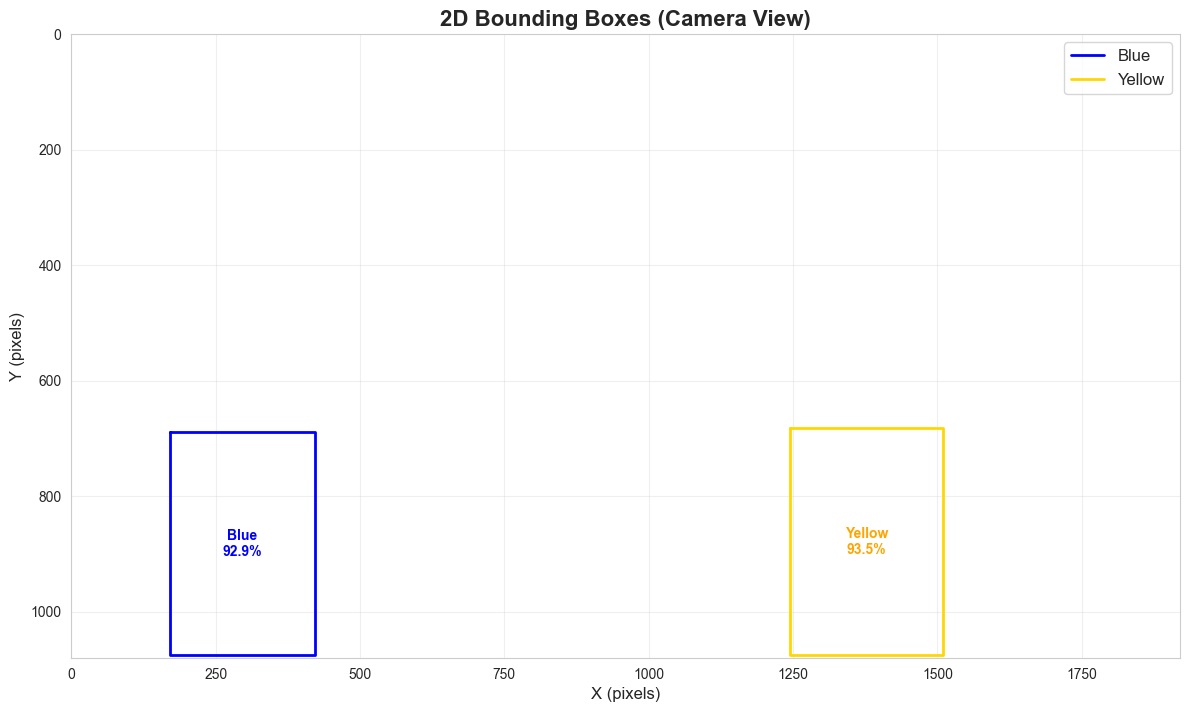

In [ ]:
# Assume camera resolution (adjust based on your camera)
img_width, img_height = 1920, 1080

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, img_width)
ax.set_ylim(img_height, 0)  # Invert Y axis for image coordinates
ax.set_aspect('equal')
ax.set_title('2D Bounding Boxes (Camera View)', fontsize=16, fontweight='bold')
ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)

# Draw blue objects
for obj in blue_objects:
    corners = obj['bounding_box_2d']['corners']
    x_coords = [c['kp'][0] for c in corners] + [corners[0]['kp'][0]]
    y_coords = [c['kp'][1] for c in corners] + [corners[0]['kp'][1]]
    ax.plot(x_coords, y_coords, 'b-', linewidth=2, label='Blue' if obj == blue_objects[0] else '')
    # Add label
    center_x = np.mean([c['kp'][0] for c in corners])
    center_y = np.mean([c['kp'][1] for c in corners])
    ax.text(center_x, center_y, f"Blue\n{obj['confidence']:.1f}%", 
            ha='center', va='center', color='blue', fontweight='bold', fontsize=10)

# Draw yellow objects
for obj in yellow_objects:
    corners = obj['bounding_box_2d']['corners']
    x_coords = [c['kp'][0] for c in corners] + [corners[0]['kp'][0]]
    y_coords = [c['kp'][1] for c in corners] + [corners[0]['kp'][1]]
    ax.plot(x_coords, y_coords, color='gold', linewidth=2, label='Yellow' if obj == yellow_objects[0] else '')
    # Add label
    center_x = np.mean([c['kp'][0] for c in corners])
    center_y = np.mean([c['kp'][1] for c in corners])
    ax.text(center_x, center_y, f"Yellow\n{obj['confidence']:.1f}%", 
            ha='center', va='center', color='orange', fontweight='bold', fontsize=10)

ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Visualized 3D Positions

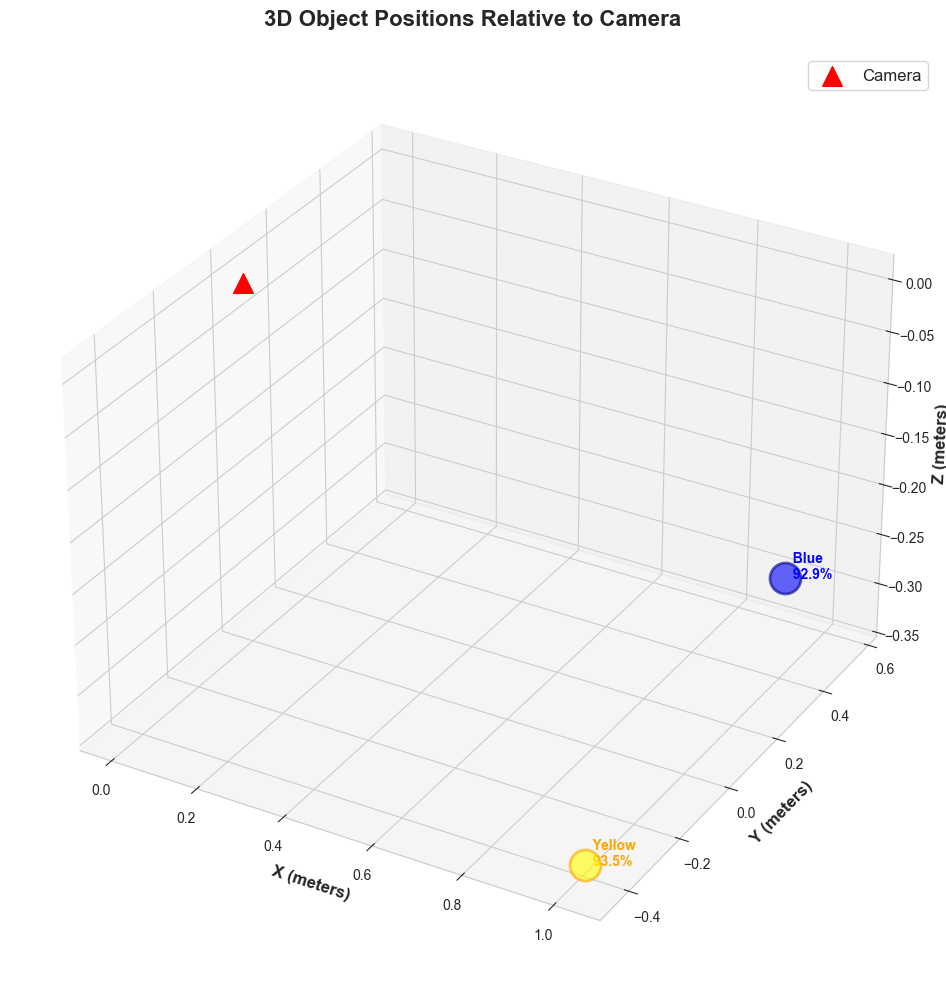

In [ ]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='persp')

# Explicitly use Axes3D for 3D plotting
# Plot blue objects
for obj in blue_objects:
    pos = obj['position']
    dims = obj['dimensions_3d']
    ax.scatter(pos[0], pos[1], pos[2], c='blue', s=500, marker='o', alpha=0.6, edgecolors='darkblue', linewidth=2)
    ax.text(pos[0], pos[1], pos[2], f"  Blue\n  {obj['confidence']:.1f}%", color='blue', fontweight='bold')

# Plot yellow objects
for obj in yellow_objects:
    pos = obj['position']
    dims = obj['dimensions_3d']
    ax.scatter(pos[0], pos[1], pos[2], c='yellow', s=500, marker='o', alpha=0.6, edgecolors='orange', linewidth=2)
    ax.text(pos[0], pos[1], pos[2], f"  Yellow\n  {obj['confidence']:.1f}%", color='orange', fontweight='bold')

# Plot camera at origin
ax.scatter(0, 0, 0, c='red', s=200, marker='^', label='Camera')

ax.set_xlabel('X (meters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (meters)', fontsize=12, fontweight='bold')
ax.set_zlabel('Z (meters)', fontsize=12, fontweight='bold')
ax.set_title('3D Object Positions Relative to Camera', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Providing Statistical Comparisons

In [ ]:
comparison = df.groupby('Label').agg({
    'Confidence (%)': ['mean', 'min', 'max'],
    'Position_X': 'mean',
    'Position_Y': 'mean',
    'Position_Z': 'mean',
    'Velocity_X': 'mean',
    'Velocity_Y': 'mean',
    'Velocity_Z': 'mean',
    'Width_3D': 'mean',
    'Height_3D': 'mean',
    'Depth_3D': 'mean'
}).round(4)

print("="*80)
print("COMPARATIVE STATISTICS: BLUE vs YELLOW")
print("="*80)
print(comparison)

COMPARATIVE STATISTICS: BLUE vs YELLOW
       Confidence (%)               Position_X Position_Y Position_Z  \
                 mean    min    max       mean       mean       mean   
Label                                                                  
blue            92.87  92.87  92.87     0.9227     0.5637    -0.3008   
yellow          93.51  93.51  93.51     1.0257    -0.4366    -0.3306   

       Velocity_X Velocity_Y Velocity_Z Width_3D Height_3D Depth_3D  
             mean       mean       mean     mean      mean     mean  
Label                                                                
blue       0.0445     0.0183     0.0017   0.2194    0.3387   0.2194  
yellow    -0.0044    -0.0192     0.0007   0.2582    0.3837   0.2582  


## 7. Creating Comprehensive Comparisons Dashboard

### Dashboard Statistical Visualization with Seaborn

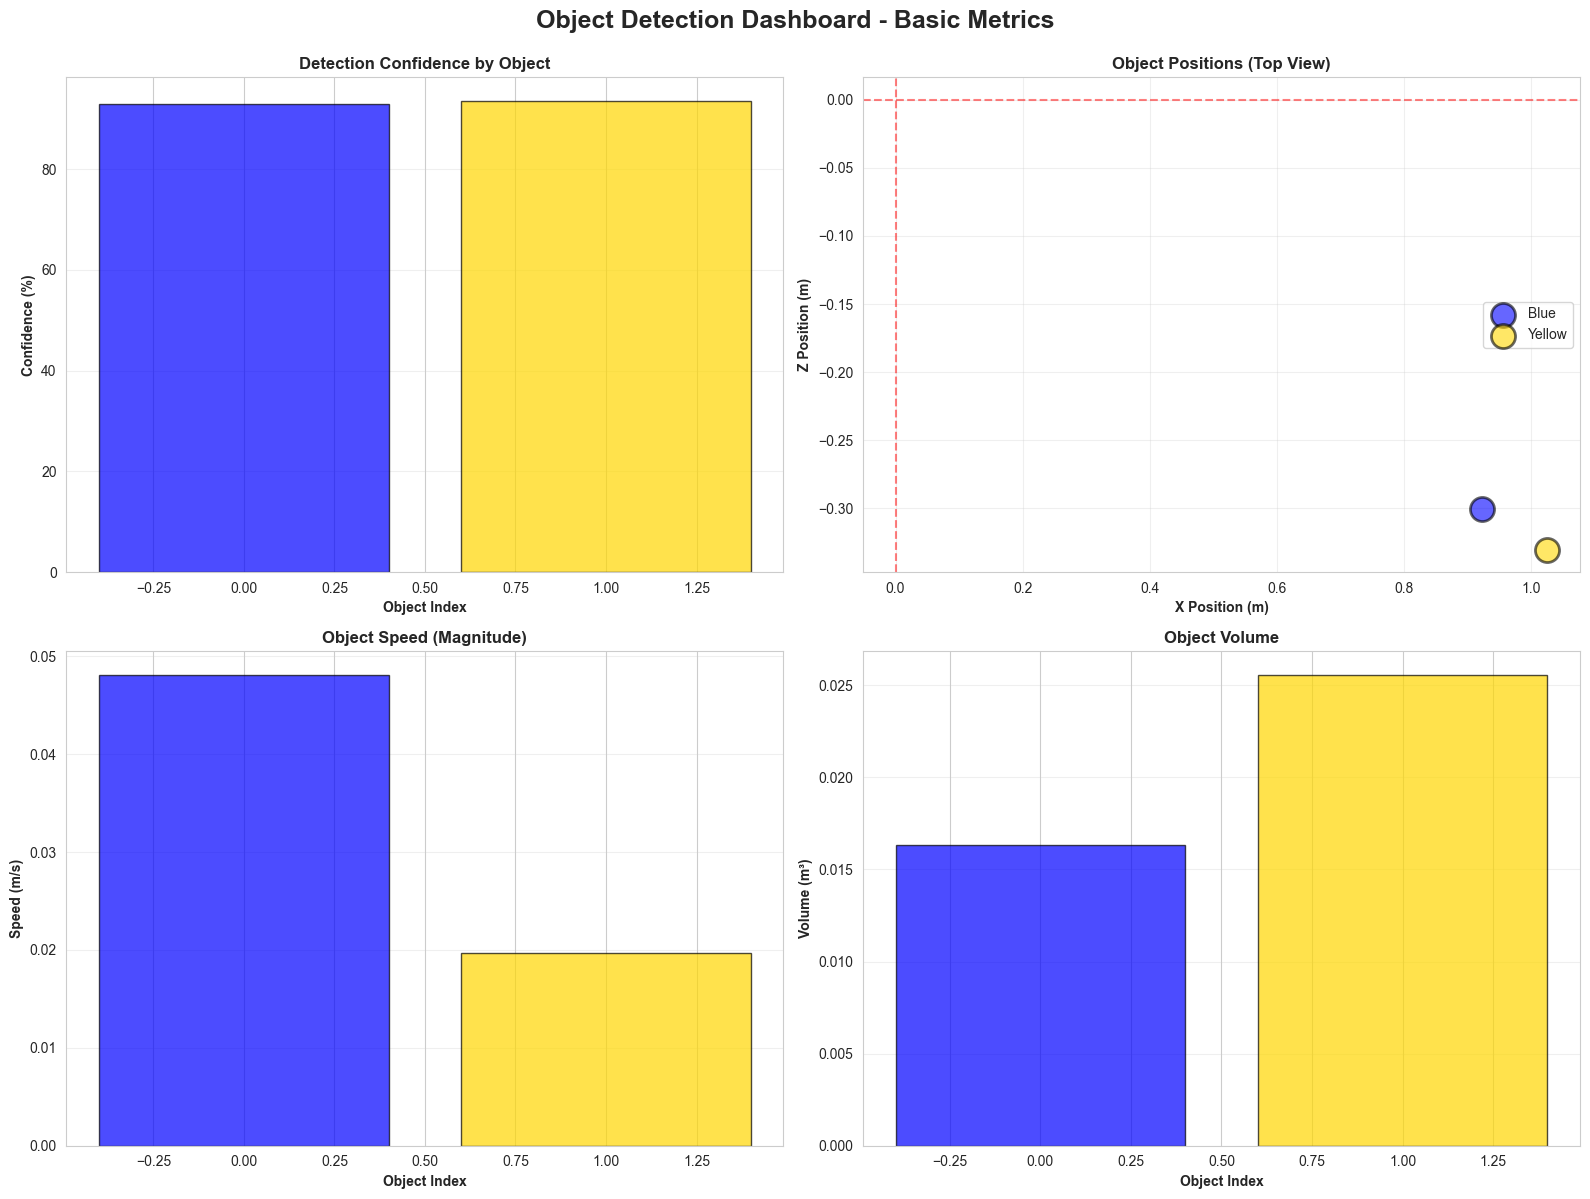

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Object Detection Dashboard - Basic Metrics', fontsize=18, fontweight='bold', y=0.995)

# Confidence scores
ax1 = axes[0, 0]
colors = ['blue' if label == 'blue' else 'gold' for label in df['Label']]
ax1.bar(range(len(df)), df['Confidence (%)'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Object Index', fontweight='bold')
ax1.set_ylabel('Confidence (%)', fontweight='bold')
ax1.set_title('Detection Confidence by Object', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Position distribution
ax2 = axes[0, 1]
for label, color in [('blue', 'blue'), ('yellow', 'gold')]:
    subset = df[df['Label'] == label]
    ax2.scatter(subset['Position_X'], subset['Position_Z'], 
                s=300, c=color, alpha=0.6, edgecolors='black', linewidth=2, label=label.capitalize())
ax2.set_xlabel('X Position (m)', fontweight='bold')
ax2.set_ylabel('Z Position (m)', fontweight='bold')
ax2.set_title('Object Positions (Top View)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Camera')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Velocity comparison
ax3 = axes[1, 0]
velocities = np.sqrt(df['Velocity_X']**2 + df['Velocity_Y']**2 + df['Velocity_Z']**2)
colors = ['blue' if label == 'blue' else 'gold' for label in df['Label']]
ax3.bar(range(len(df)), velocities, color=colors, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Object Index', fontweight='bold')
ax3.set_ylabel('Speed (m/s)', fontweight='bold')
ax3.set_title('Object Speed (Magnitude)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Size comparison
ax4 = axes[1, 1]
volumes = df['Width_3D'] * df['Height_3D'] * df['Depth_3D']
colors = ['blue' if label == 'blue' else 'gold' for label in df['Label']]
ax4.bar(range(len(df)), volumes, color=colors, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Object Index', fontweight='bold')
ax4.set_ylabel('Volume (m³)', fontweight='bold')
ax4.set_title('Object Volume', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Exporting the Data to CSV Files

In [ ]:
output_file = 'parsed_camera_objects.csv'
df.to_csv(output_file, index=False)
print(f"Data exported to: {output_file}")

df[df['Label'] == 'blue'].to_csv('blue_objects.csv', index=False)
df[df['Label'] == 'yellow'].to_csv('yellow_objects.csv', index=False)
print(f"Blue objects exported to: blue_objects.csv")
print(f"Yellow objects exported to: yellow_objects.csv")

Data exported to: parsed_camera_objects.csv
Blue objects exported to: blue_objects.csv
Yellow objects exported to: yellow_objects.csv
